# demo 3 concating signal

Here we would like to exam 1 experimental idea: we gonna have multiple trials of measured data, for each trail, we gonna apply ned feedback before measurement starts, then we gonna concat all of those short measurement to a long measuremnt, then we gonna extract freq signal from that long signal.
 


In [ ]:
from scipy.optimize import least_squares
import numpy as np
import matplotlib.pyplot as plt
import scipy
import function as fc

In [ ]:
import h5py

h5_file = 'data\\2026-01-19 1024x2 noise data MeasureTime=0.011071397970549715 k=0.0027 T=273 Q=18000 f0=8169.7 initial ratio=100.h5'

with h5py.File(h5_file, "r") as f:
    sig_low = f["sig_low"][:]
    noise_0_low_l = f["noise_0_low_l"][:]
    noise_0_high_l = f["noise_0_high_l"][:]
    noise_eq = f["noise_eq"][:]

t = sig_low[:,0]+sig_low[1,0]
dt = t[1]-t[0]

In [ ]:
Q = 18000
T = 273
k = 0.0027
w0 = 8169.7 * 2 * np.pi
dt = sig_low[1, 0] - sig_low[0, 0]
t = sig_low[:, 0] + sig_low[1, 0]  # time starts at dt

# 1 setting up signal

In [ ]:
import matplotlib.pyplot as plt
for i in [1,101,201,401,701,1001]:
    plt.plot(sig_low[:,0],noise_eq[i*len(sig_low[:,0]):(i+1)*len(sig_low[:,0]),0],label="noise_negoff_"+str(i))
    plt.plot(sig_low[:,0],noise_0_low_l[i][:,0],label="noise_negon_"+str(i))
    plt.xlabel('time(s)')
    plt.ylabel('pos noise(m)')
    plt.legend()
    plt.show()

# 2 setting up function

## 2.1 setting up fitting function

we would like to set a non-linear leat square fitter for our signal, we decide to use scipy.least square, 

In [ ]:
# import numpy as np


def pos2sig(x, V0, lam, phi_b=0, V_bias=0):
    return V0 * np.sin(2 * np.pi * x / lam + phi_b) + V_bias



def makey(t, E, V0, x0, phi0, phiB, w):
    psi = w * t + phi0
    cpsi = np.cos(psi)
    Theta = x0 * E * cpsi + phiB
    sTh = np.sin(Theta)
    yhat = V0 * sTh
    return yhat

def makeJ(t, E, V0, x0, phi0, phiB, w):
    psi = w * t + phi0
    cpsi = np.cos(psi)
    spsi = np.sin(psi)
    Theta = x0 * E * cpsi + phiB
    sTh = np.sin(Theta)
    cTh = np.cos(Theta)
    J = np.empty((t.size, 4), dtype=float)  # d yhat / d params
    J[:, 0] = V0 * cTh * (E * cpsi)
    J[:, 1] = V0 * cTh * (-x0 * E * spsi)
    J[:, 2] = V0 * cTh
    J[:, 3] = V0 * cTh * (-x0 * E * t * spsi)
    return J



def make_fun_jac(t, E, V0):
    t = np.asarray(t, float)
    def fun(p, y):
        x0, phi0, phiB, w = p
        yhat = makey(t, E, V0, x0, phi0, phiB, w)
        return y - yhat

    def jac(p, y):
        x0, phi0, phiB, w = p
        J = makeJ(t, E, V0, x0, phi0, phiB, w)
        return -J

    return fun, jac


def fit_many_warmstart(
    Y, t, E, V0, p0, bounds=None, loss="huber", x_scale=None, method="dogbox"
):
    """
    This function is used to fit our signal with warm start method, wo cut our signal into small
    pieces, and when we fit it, we want to approx the initial guess for the Ith trail by the
    fitting result of (I-1)th trail, which is called warm start.
    Parameters:
        Y [list of array]: each array is the signal we want to fit, which is a 2D array with the
        first column as the time and the second column as the signal.
        t [array]: the time array of the signal.
        E [array]: the envelope array of the signal.
        V0 [float]: the V0 of the signal.
        p0 [array]: the initial guess of the parameters.
        bounds [tuple]: the bounds of the parameters.
        loss [str]: the loss function we want to use.
        x_scale [array]: the scale of the parameters.
        method [str]: the method we want to use to fit the signal.
    Returns:
        P [array]: the fitting result of the parameters.
        costs [array]: the cost of the fitting.
        nfevs [array]: the number of function evaluations.
    """
    # Pre-calculate E to avoid exp function slowing down the process
    fun, jac = make_fun_jac(t, E, V0)

    n_seg = len(Y)
    P = np.empty((n_seg, 4), float)
    costs = np.empty(
        n_seg, float
    )  # Residual cost for each segment (for linear loss = 0.5*sum(r^2))
    nfevs = np.empty(n_seg, int)  # Number of function evaluations for each segment
    p = np.array(p0, float)

    # The parameters have different units: use x_scale so that xtol behaves "relatively" the same for all components.
    # If not provided, use the magnitude of initial bounds; if 0, use 1e-12 as a last resort.
    if x_scale is None:
        x_scale = [
            np.max([np.abs(bounds[1][i] - bounds[0][i]), 1e-10])
            for i in range(len(bounds[0]))
        ]

    for i, y in enumerate(Y):
        res = least_squares(
            lambda pp: fun(pp, y),
            x0=p,
            jac=lambda pp: jac(pp, y),
            method=method,
            bounds=bounds if bounds is not None else (-np.inf, np.inf),
            loss=loss,
            x_scale=x_scale,
            max_nfev=50,  # For small problems, don't let it run too long
            xtol=1e-15,
            ftol=1e-15,
            gtol=1e-15,
        )

        P[i] = res.x
        if n_seg > 1:
            p = P[i]
            p[1] = (t[-1] + t[1] - t[0]) * P[i][-1] + p[1]
            p[1] = (p[1] + np.pi) % (2 * np.pi) - np.pi  # Keep phase between -pi and pi
            p[0] = P[i][0] * E[-1] * E[1] / E[0]

            if bounds is not None:
                bounds[0][0] = bounds[0][0] * E[-1] * E[1] / E[0]
                bounds[1][0] = bounds[1][0] * E[-1] * E[1] / E[0]
        costs[i] = res.cost
        nfevs[i] = res.nfev
    return P, costs, nfevs

## 2.2 setting up Hilbert filter

We use Hilbert filter to: 1. change real cos signal to complex exponenitial signal; 2. extract freq from measured signal 

In [ ]:

def getCantileverHilbertFilter(
    data,
    t_cycle,
    f_band,
    t_rip,
    if_window,
    if_bandpass,
    if_rippleless,
    bpstyle="gaussian",
):
    '''
    This function is used to apply a Hilbert filter to a signal.
    Parameters:
        data[array]:2D array, the first column is the time, the second column is the signal.
        t_cycle[float]: the cyclize time of the signal.
        f_band[float]: the bandpass width,unit is kHz.
        t_rip[float]: the ripple time of the signal.
        if_window[bool]: whether to apply a window to the signal.
        if_bandpass[bool]: whether to apply a bandpass filter to the signal.
        if_rippleless[bool]: whether to apply a rippleless filter to the signal.
        bpstyle: the style of the bandpass filter. 
    Returns:
        sIFT[array]:the signal after Hilbert filter.
    '''

    # create numpy array from incoming waveform
    arr = np.array(data)
    # extract ordinate data array
    x, y = arr[:, 0], arr[:, 1]
    # time step
    dt = x[1] - x[0]
    # # apply time mask
    # x, y = fc.time_mask_binarate(x, y, dt, "start")
    # force data to start/end at zero, prevent edge effect on the beginning and end of the signal
    if if_window:
        w = fc.time_window_cyclicize(x, y, dt, t_cycle)
        y = y * w
    # fourier transform (F.T.)
    freq, sFT = fc.fft(x, y, dt)
    # complex Hilbert transform
    filt = fc.freq_filter_Hilbert_complex(freq, sFT)
    if if_bandpass:
        # apply 1kHz wide bandpass filter
        bp = fc.freq_filter_bp(freq, sFT, filt, f_band, style=bpstyle)
    else:
        bp = sFT
    # set up filter to remove ripples
    if if_rippleless:
        mask, x_rippleless = fc.time_mask_rippleless(x, dt, t_rip)
    else:
        mask = np.ones_like(x, dtype=bool)
    # Inverse F.T.
    sIFT, p, a = fc.ifft(sFT, dt, filt, bp, mask)
    return sIFT


def getCantileverFreq(
    data,
    t_cycle, 
    t_rip, 
    dt_chunk_target=221.34e-6, 
    bpstyle="gaussian"
):
    '''
    This function is used to apply a Hilbert filter to a signal, then fit the phase vs. time data, and compute the frequency.
    Parameters:
        data[array]:2D array, the first column is the time, the second column is the signal.
        t_cycle[float]: the cyclize time of the signal.
        f_band[float]: the bandpass width,unit is kHz.
        t_rip[float]: the ripple time of the signal.
        dt_chunk_target[float]: the target chunk time of the frequency signal.
        bpstyle: the style of the bandpass filter. 
    Returns:
        avg_fc[float]: the frequency signal.
    '''

    # create numpy array from incoming waveform
    arr = np.array(data)
    # extract ordinate data array
    x, y = arr[:, 0], arr[:, 1]
    # time step
    dt = x[1] - x[0]
    # apply time mask
    # x, y = time_mask_binarate(x, y, dt, "middle")
    # force data to start/end at zero, prevent edge effect on the beginning and end of the signal
    w = fc.time_window_cyclicize(x, y, dt, t_cycle)
    # apply cyclicizing window to signal
    y = y * w
    # fourier transform (F.T.)
    freq, sFT = fc.fft(x, y, dt)
    # complex Hilbert transform
    filt = fc.freq_filter_Hilbert_complex(freq, sFT)
    # apply 1kHz wide bandpass filter
    bp = fc.freq_filter_bp(freq, sFT, filt, 1.00, style=bpstyle)
    # set up filter to remove ripples
    mask, x_rippleless = fc.time_mask_rippleless(x, dt, t_rip)
    # Inverse F.T.
    sIFT, p, a = fc.ifft(sFT, dt, filt, bp, mask)
    # fit phase vs. time data
    x_sub_middle, slope = fc.fit_phase(sIFT, p, a, dt, x, dt_chunk_target)
    # compute average fc
    avg_fc = np.mean(slope)

    return slope


# 3. Extracting freq signal

In [ ]:
#setting up parameters
x0 = 60 #nm, amplitude of the signal
lam = 1314 #nm, wavelength of the decection laser
V0 = 1 #V, 1nm->1V volatge signal
std_shot = 0.0005 #V, standard deviation of the shot noise
rate = 1 # amplification ratio of our thermal noise
t = sig_low[:, 0] + sig_low[1, 0]  #s, time array
dt = t[1] - t[0]
dw = 0.01 * 2 * np.pi# rad/s, freq shift of our signal
w1 = 2 * np.pi * 8169.4# rad/s, charateristic freq of our signal
w2 = w1 + dw# rad/s, high freq of our signal

#setting up hilbert filter parameters
E = np.exp(
    -t * w0 / (Q + 200) / 2
)  #estimated exponential decay of our signal, Q is setted a little bit off on purpose

pi = 0.5 * np.pi

# We want our signal to have frequency variations, so the frequency changes every N1 signals, and in total changes N2 times.
N1 = 4 * 16# every N1 signal has a different freq
N2 = int(1024 / 2 / 16)# we have N2 segments of signal
t_rip = 5.5e-4# s, time of the ripple of our signal
t_cycle = 1e-4# s, time of the cycle of our signal
dt_chunk_target = 221e-6#s, target chunk time of the frequency signal

n1 = 0
n2 = 0

# list of signals
sig_concat = np.array([]) # concatenated noise-free signal
sig_concat_n0 = np.array([]) # concatenated signal with negative on noise
sig_continuous = np.array([]) # continuous noise-free signal
sig_continuous_n0 = np.array([]) # continuous signal with negative on noise
sig_eq = np.array([]) # line sequence signal with negative off noise
p = np.array([]) # phase array


for i in range(N1):

    for j in range(N2):
        # setting up signal parameters for each measurment trails
        amp_sig = (
            1 + 0.002 * np.random.rand()
        )  # assuming our initial amplitude is kept at a very close state
        phi0_sig = 0.5 * np.pi * (np.random.rand() - 0.5) #initial phase of the signal
        V_b = 0 #bias voltage
        phi_b = 0.001 * np.random.rand() #phase bias

        # setting up the rad freq of the signal
        if i % 2 == 0:
            w = w1 #freq of the signal
            noise = noise_0_low_l[n1][:, 0]#picking which noise to use
            n1 += 1
        else:
            w = w2 #freq of the signal
            noise = noise_0_high_l[n2][:, 0] #picking which noise to use
            n2 += 1

        # setting up the signal
        # signal without noise
        signal = pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * np.exp(-t / Q * w1 / 2),
            V0,
            lam,
            phi_b=phi_b,
            V_bias=V_b,
        )
        # signal with neg on noise
        signal_n0 = pos2sig(
            amp_sig * x0 * np.cos(w * t + phi0_sig) * np.exp(-t / Q * w1 / 2)
            + rate**1 * 10**9 * noise
            + std_shot * np.random.randn(len(noise)),
            V0,
            lam,
            phi_b=phi_b,
            V_bias=V_b,
        )
        # sig_right = pos2sig(x0*np.cos(w*t+pi),V0,lam,phi_b = 0,V_bias = 0)

        phase = t * w + pi#phase of the continuous signal
        #continuous signal without noise
        sig_right = pos2sig(
            x0 * np.cos(phase) * np.exp(-t / Q * w1 / 2), V0, lam, phi_b=phi_b, V_bias=0
        )
        #continuous signal with neg on noise
        sig_right_n0 = pos2sig(
            x0 * np.cos(phase) * np.exp(-t / Q * w1 / 2)
            + rate**1 * 10**9 * noise
            + std_shot * np.random.randn(len(noise)),
            V0,
            lam,
            phi_b=0,
            V_bias=0,
        )
        pi = phase[-1]
        #phase array
        p = np.concatenate([p, phase])

        #-------------------------------------------------
        # making our signal to be continuous
        # since we are cooncatnating multiple ring-down signals with different amplitude and discontinuous phase, we wan to make our signal as continuous as possible
        # since we want to concat multiple signals, we we want to suppresss the decaying of our signal
        signal = (signal - np.mean(signal)) / E
        signal_n0 = (signal_n0 - np.mean(signal_n0)) / E

        # applying Hilbert filter to our signal, so we can ADJUST THE PHASE
        sig_bp = getCantileverHilbertFilter(
            np.array([t, signal]).T,
            t_cycle=5e-4,
            f_band=1,
            t_rip=t_rip,
            if_window=True,
            if_bandpass=True,
            if_rippleless=False,
            bpstyle="gaussian",
        )
        sig_bp_n0 = getCantileverHilbertFilter(
            np.array([t, signal_n0]).T,
            t_cycle=5e-4,
            f_band=1,
            t_rip=t_rip,
            if_window=True,
            if_bandpass=True,
            if_rippleless=False,
            bpstyle="gaussian",
        )

        # cut the start and the end of our signal, so we can avoid the edge effect
        di = int(t_rip / dt)
        sig_bp = sig_bp[di + 1 : -di - 1]
        sig_bp_n0 = sig_bp_n0[di + 1 : -di - 1]
        # extracting the phase of our signal
        phase_signal_fit = np.unwrap(np.angle(sig_bp))
        phase_signal_n0_fit = np.unwrap(np.angle(sig_bp_n0))

        # normalizing the signal, we want our signal to be continuous, so we normalize the amplutude signal to be 1
        sig_bp = sig_bp / np.abs(sig_bp)
        sig_bp_n0 = sig_bp_n0 / np.abs(sig_bp_n0)

        # phase_bp = np.unwrap(np.angle(sig_bp))
        # phase_bp_n0 = np.unwrap(np.angle(sig_bp_n0))

        if i + j > 0:  # as long as it is not the first epoch
            # pure discontinuous signal
            phase_i = phase_signal_fit[0]  # the second sequence starts to correct the phase to the last phase
            sig_bp = sig_bp * np.exp(1j * (phase_j - phase_i))#adjusting the phase of the signal
            phase_signal_fit = phase_signal_fit + phase_j - phase_i
            # pure discontinuous signal with neg on noise
            phase_i_n0 = phase_signal_n0_fit[0]  # the second sequence starts to correct the phase to the last phase
            sig_bp_n0 = sig_bp_n0 * np.exp(1j * (phase_j_n0 - phase_i_n0))#adjusting the phase of the signal with neg on noise
            phase_signal_n0_fit = phase_signal_n0_fit + phase_j_n0 - phase_i_n0

        phase_j = phase_signal_fit[-1]  # recoding the endding phase of last sequence
        phase_j_n0 = phase_signal_n0_fit[-1]  # recoding the endding phase of last sequence

        # concatenating the signal
        sig_concat = np.concatenate([sig_concat, sig_bp[:-1]])
        sig_concat_n0 = np.concatenate([sig_concat_n0, sig_bp_n0[:-1]])
        sig_continuous = np.concatenate([sig_continuous, sig_right])
        sig_continuous_n0 = np.concatenate([sig_continuous_n0, sig_right_n0])

# setting up the continuous signal with neg off noise
sig_eq = pos2sig(
    x0 * np.cos(p)
    + rate**1 * 10**9 * noise_eq[:, 0]
    + std_shot * np.random.randn(len(p)),
    V0,
    lam,
    phi_b=phi_b,
    V_bias=V_b,
)

sig_eq = sig_eq - np.mean(sig_eq)

# Since the input for our Hilbert filter requires a format like np.array([time, signal]).T, we need to convert our signals into this form.
t_x_concat = np.arange(1, len(sig_concat) + 1) * dt
sig_concat = np.array([t_x_concat, np.real(sig_concat)]).T
sig_concat_n0 = np.array([t_x_concat, np.real(sig_concat_n0)]).T
t_x_continuous = np.arange(1, len(sig_continuous) + 1) * dt
sig_continuous = np.array([t_x_continuous, sig_continuous]).T
t_x_continuous_n0 = np.arange(1, len(sig_continuous_n0) + 1) * dt
sig_continuous_n0 = np.array([t_x_continuous_n0, sig_continuous_n0]).T
t_x_eq = np.arange(1, len(sig_eq) + 1) * dt
sig_eq = np.array([t_x_eq, sig_eq]).T

# extracting the freq of the signal
f_concat = getCantileverFreq(
    sig_concat, t_cycle, t_rip, dt_chunk_target=221.34e-6, bpstyle="gaussian"
)
f_concat_n0 = getCantileverFreq(
    sig_concat_n0, t_cycle, t_rip, dt_chunk_target=221.34e-6, bpstyle="gaussian"
)
f_continuous = getCantileverFreq(
    sig_continuous, t_cycle, t_rip, dt_chunk_target=221.34e-6, bpstyle="gaussian"
)
f_continuous_n0 = getCantileverFreq(
    sig_continuous_n0, t_cycle, t_rip, dt_chunk_target=221.34e-6, bpstyle="gaussian"
)
f_eq = getCantileverFreq(
    sig_eq, t_cycle, t_rip, dt_chunk_target=221.34e-6, bpstyle="gaussian"
)

# fft of the freq signal
f_concat_fft = np.fft.fft(f_concat)
f_concat_fft_abs = (f_concat_fft) / len(f_concat_fft)
f_concat_fft_freqs = np.fft.fftfreq(len(f_concat), d=dt_chunk_target)

f_concat_n0_fft = np.fft.fft(f_concat_n0)
f_concat_n0_fft_abs = (f_concat_n0_fft) / len(f_concat_n0_fft)
f_concat_n0_fft_freqs = np.fft.fftfreq(len(f_concat_n0), d=dt_chunk_target)

f_continuous_fft = np.fft.fft(f_continuous)
f_continuous_fft_abs = (f_continuous_fft) / len(f_continuous_fft)
f_continuous_fft_freqs = np.fft.fftfreq(len(f_continuous), d=dt_chunk_target)

f_continuous_n0_fft = np.fft.fft(f_continuous_n0)
f_continuous_n0_fft_abs = (f_continuous_n0_fft) / len(f_continuous_n0_fft)
f_continuous_n0_fft_freqs = np.fft.fftfreq(len(f_continuous_n0), d=dt_chunk_target)

f_eq_fft = np.fft.fft(f_eq)
f_eq_fft_abs = (f_eq_fft) / len(f_eq_fft)
f_eq_fft_freqs = np.fft.fftfreq(len(f_eq), d=dt_chunk_target)



In [ ]:
# plotting the power spectrum of the freq signal
i1 = 2
i2 = 200
plt.figure(figsize=(15, 12))
plt.title("log10 abs FFT of freq  ")
plt.plot(
    f_concat_fft_freqs[i1:i2],
    np.log10(np.abs(f_concat_fft_abs[i1:i2])),
    label="concated signal",
)
plt.plot(
    f_concat_n0_fft_freqs[i1:i2],
    np.log10(np.abs(f_concat_n0_fft_abs[i1:i2])),
    label="concated signal with neg on noise",
)
plt.plot(
    f_continuous_fft_freqs[i1:i2],
    np.log10(np.abs(f_continuous_fft_abs[i1:i2])),
    label="continuous signal",
)
plt.plot(
    f_continuous_n0_fft_freqs[i1:i2],
    np.log10(np.abs(f_continuous_n0_fft_abs[i1:i2])),
    label="continus signal with neg on noise",
)
plt.plot(
    f_eq_fft_freqs[i1:i2], np.log10(np.abs(f_eq_fft_abs[i1:i2])), label="continuous signal with neg off noise"
)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()


plt.figure(figsize=(15, 12))
plt.title("log10 img FFT of freq " )
plt.plot(
    f_concat_fft_freqs[i1:i2],
    np.log10(np.abs(np.imag(f_concat_fft_abs[i1:i2]))),
    label="concated signal",
)
plt.plot(
    f_concat_n0_fft_freqs[i1:i2],
    np.log10(np.abs(np.imag(f_concat_n0_fft_abs[i1:i2]))),
    label="concated signal with neg on noise",
)
plt.plot(
    f_continuous_fft_freqs[i1:i2],
    np.log10(np.abs(np.imag(f_continuous_fft_abs[i1:i2]))),
    label="continuous signal",
)
plt.plot(
    f_continuous_n0_fft_freqs[i1:i2],
    np.log10(np.abs(np.imag(f_continuous_n0_fft_abs[i1:i2]))),
    label="continus signal with neg on noise",
)
plt.plot(
    f_eq_fft_freqs[i1:i2],
    np.log10(np.abs(np.imag(f_eq_fft_abs[i1:i2]))),
    label="continuous signal with neg off noise",
)

plt.legend()

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

plt.show()

We found that only when the phase of our signal is completely continuous does the noise floor improve, and this improvement appears in the low-frequency region. But does this mean the freq noise is really suppressed by the neg feedback?

 # 4 discontinious of noise's phase
 We worry that for concatenated signals, the observed noise floor reduction is due to discontinuities in the noise phase. In other words, for our negative offset signal, if we segment it, randomize the order, and then concatenate, we will also observe a similar noise floor reduction.

# First shuffle the eq order



In [16]:

noise_segments = np.split(noise_eq[:, 0], 2048)
np.random.shuffle(noise_segments)
noise_negoff_rand = np.concatenate(noise_segments)

In [ ]:
import matplotlib.pyplot as plt
for i in [1,101,201,401,701,1001]:
    plt.plot(noise_eq[i*len(sig_low[:,0])-100:(i)*len(sig_low[:,0])+100,0],label="noise_negoff_"+str(i))
    plt.plot(noise_negoff_rand[i*len(sig_low[:,0])-100:(i)*len(sig_low[:,0])+100],label="noise_negoff_rand_"+str(i))
    plt.xlabel('time(s)')
    plt.ylabel('pos noise(m)')
    plt.title('noise_negoff_rand vs noise_negoff')
    plt.legend()
    plt.show()

In [19]:
#setting up parameters
x0 = 60 #nm, amplitude of the signal
lam = 1314 #nm, wavelength of the decection laser
V0 = 1 #V, 1nm->1V volatge signal
std_shot = 0.0005 #V, standard deviation of the shot noise
rate = 1 # amplification ratio of our thermal noise
t = sig_low[:, 0] + sig_low[1, 0]  #s, time array
dt = t[1] - t[0]
dw = 0.01 * 2 * np.pi# rad/s, freq shift of our signal
w1 = 2 * np.pi * 8169.4# rad/s, charateristic freq of our signal
w2 = w1 + dw# rad/s, high freq of our signal

#setting up hilbert filter parameters
E = np.exp(
    -t * w0 / (Q + 200) / 2
)  #estimated exponential decay of our signal, Q is setted a little bit off on purpose

pi = 0.5 * np.pi

# We want our signal to have frequency variations, so the frequency changes every N1 signals, and in total changes N2 times.
N1 = 2 * 16# every N1 signal has a different freq
N2 = int(1024 / 2 / 16)# we have N2 segments of signal
t_rip = 5.5e-4# s, time of the ripple of our signal
t_cycle = 1e-4# s, time of the cycle of our signal
dt_chunk_target = 221e-6#s, target chunk time of the frequency signal

n = 0
n1 = 0
n2 = 0

# list of signals
sig_continuous = np.array([])
sig_continuous_negon = np.array([])
sig_continuous_negoff = np.array([])
sig_eq = np.array([])
p = np.array([])


for i in range(N1):

    for j in range(N2):
        #setting up signal parameters for each measurment trails
        amp_sig = (1+0.002*np.random.rand())# Assume the initial amplitude stays in a very similar range
        phi0_sig = 0.5*np.pi*(np.random.rand()-0.5)#initial phase of the signal
        V_b = 0 #bias voltage
        phi_b = 0.001*np.random.rand() #phase bias

        # for this time, we decide that we not gonna simulate the freq shift sognal, we just care about the noise
        if i%2 == 0:
            w = w1
            noise_negon=noise_0_low_l[n1][:, 0]
        else:
            w = w2
            noise_negon=noise_0_high_l[n2][:, 0]

        noise_negoff=noise_negoff_rand[n*len(t):(n+1)*len(t)]
        n+=1

        p_right = w*t+phi0_sig
        phase = t*w+pi
        sig_right = pos2sig(x0*np.cos(phase)*np.exp(-t/Q*w1/2),V0,lam,phi_b = phi_b,V_bias = 0)
        sig_right_negon = pos2sig(x0*np.cos(phase)*np.exp(-t/Q*w1/2)+rate**1*10**9*noise_negon+std_shot*np.random.randn(len(noise)),V0,lam,phi_b = 0,V_bias = 0)
        sig_right_negoff = pos2sig(x0*np.cos(phase)*np.exp(-t/Q*w1/2)+rate**1*10**9*noise_negoff+std_shot*np.random.randn(len(noise)),V0,lam,phi_b = 0,V_bias = 0)
        pi = phase[-1]

        p = np.concatenate([p,phase])


        sig_continuous = np.concatenate([sig_continuous,sig_right])
        sig_continuous_negon = np.concatenate([sig_continuous_negon, sig_right_negon])
        sig_continuous_negoff = np.concatenate([sig_continuous_negoff, sig_right_negoff])

sig_eq =  pos2sig(x0*np.cos(p)+rate**1*10**9*noise_eq[:len(p),0]+std_shot*np.random.randn(len(p)),V0,lam,phi_b = phi_b,V_bias = V_b)
sig_eq = sig_eq-np.mean(sig_eq)

# fft of the freq signal
t_x_continuous = np.arange(1, len(sig_continuous)+1) * dt
sig_continuous = np.array([t_x_continuous, sig_continuous]).T

t_x_continuous_negon = np.arange(1, len(sig_continuous_negon)+1) * dt
sig_continuous_negon = np.array([t_x_continuous_negon, sig_continuous_negon]).T

t_x_continuous_negoff = np.arange(1, len(sig_continuous_negoff)+1) * dt
sig_continuous_negoff = np.array([t_x_continuous_negoff, sig_continuous_negoff]).T  

t_x_eq = np.arange(1, len(sig_eq)+1) * dt
sig_eq = np.array([t_x_eq, sig_eq]).T

# extracting freq signal
f_continuous = getCantileverFreq(sig_continuous,t_cycle,t_rip,dt_chunk_target = 221.34E-6,bpstyle='gaussian')
f_continuous_negon = getCantileverFreq(sig_continuous_negon,t_cycle,t_rip,dt_chunk_target = 221.34E-6,bpstyle='gaussian')
f_continuous_negoff = getCantileverFreq(sig_continuous_negoff,t_cycle,t_rip,dt_chunk_target = 221.34E-6,bpstyle='gaussian')
f_eq = getCantileverFreq(sig_eq,t_cycle,t_rip,dt_chunk_target = 221.34E-6,bpstyle='gaussian')

# getting power spectrum
f_continuous_fft = np.fft.fft(f_continuous)
f_continuous_fft_abs = (f_continuous_fft)/len(f_continuous_fft)
f_continuous_fft_freqs = np.fft.fftfreq(len(f_continuous), d=dt_chunk_target)

f_continuous_negon_fft = np.fft.fft(f_continuous_negon)
f_continuous_negon_fft_abs = (f_continuous_negon_fft)/len(f_continuous_negon_fft)
f_continuous_negon_fft_freqs = np.fft.fftfreq(len(f_continuous_negon), d=dt_chunk_target)

f_continuous_negoff_fft = np.fft.fft(f_continuous_negoff)
f_continuous_negoff_fft_abs = (f_continuous_negoff_fft)/len(f_continuous_negoff_fft)
f_continuous_negoff_fft_freqs = np.fft.fftfreq(len(f_continuous_negoff), d=dt_chunk_target)

f_eq_fft = np.fft.fft(f_eq)
f_eq_fft_abs = (f_eq_fft)/len(f_eq_fft)
f_eq_fft_freqs = np.fft.fftfreq(len(f_eq), d=dt_chunk_target)


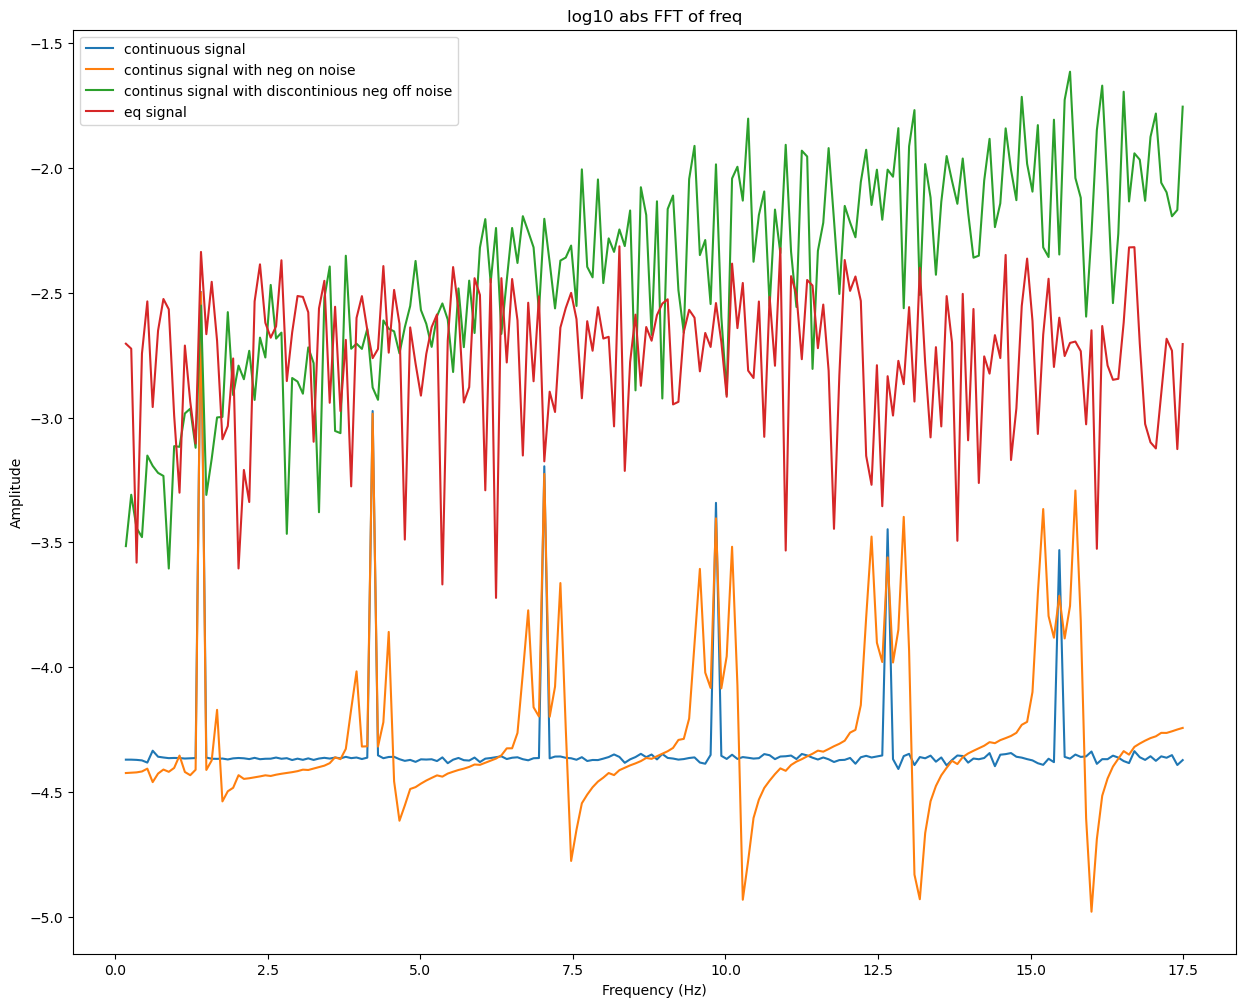

In [22]:
i1 = 2
i2 = 200
plt.figure(figsize=(15, 12))
plt.title('log10 abs FFT of freq')
# plt.plot(f_concat_fit_fft_freqs[i1:i2], np.log10(np.abs(f_concat_fit_fft_abs[i1:i2])),label = "concated signal, right freq")
# plt.plot(f_concat_n0_fit_fft_freqs[i1:i2], np.log10(np.abs(f_concat_n0_fit_fft_abs[i1:i2])),label = "concated signal with noise, fitted phase")
# plt.plot(f_concat_right_fft_freqs[i1:i2], np.log10(np.abs(f_concat_right_fft_abs[i1:i2])),label = "concated signal, right phase")
# plt.plot(f_concat_n0_right_fft_freqs[i1:i2], np.log10(np.abs(f_concat_n0_right_fft_abs[i1:i2])),label = "concated signal with noise, right phase")
plt.plot(f_continuous_fft_freqs[i1:i2], np.log10(np.abs(f_continuous_fft_abs[i1:i2])),label = "continuous signal")
plt.plot(f_continuous_negon_fft_freqs[i1:i2], np.log10(np.abs(f_continuous_negon_fft_abs[i1:i2])),label = "continus signal with neg on noise")
plt.plot(f_continuous_negoff_fft_freqs[i1:i2], np.log10(np.abs(f_continuous_negoff_fft_abs[i1:i2])),label = "continus signal with discontinious neg off noise")
plt.plot(f_eq_fft_freqs[i1:i2], np.log10(np.abs(f_eq_fft_abs[i1:i2])),label = "eq signal")
# plt.plot(f_direct_concat_fft_freqs[i1:i2], np.log10(f_direct_concat_fft_abs[i1:i2]),label = "direct concat signal")
# plt.plot(f_direct_concat_n0_fft_freqs[i1:i2], np.log10(f_direct_concat_n0_fft_abs[i1:i2]),label = "direct concat signal with noise")
# plt.plot(f_concat_tossgap_fft_freqs[i1:i2], np.log10(f_concat_tossgap_fft_abs[i1:i2]),label = "concated signal with tossgap")
# plt.plot(f_concat_n0_tossgap_fft_freqs[i1:i2], np.log10(f_concat_n0_tossgap_fft_abs[i1:i2]),label = "concated signal with noise and tossgap")
plt.legend()

# plt.ylim(-2.,0)
# plt.ylim(np.min(np.log10(freq_fft_abs[10:10000])*2),np.max(np.log10(freq_fft_abs[10:10000])*2))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')

plt.show()

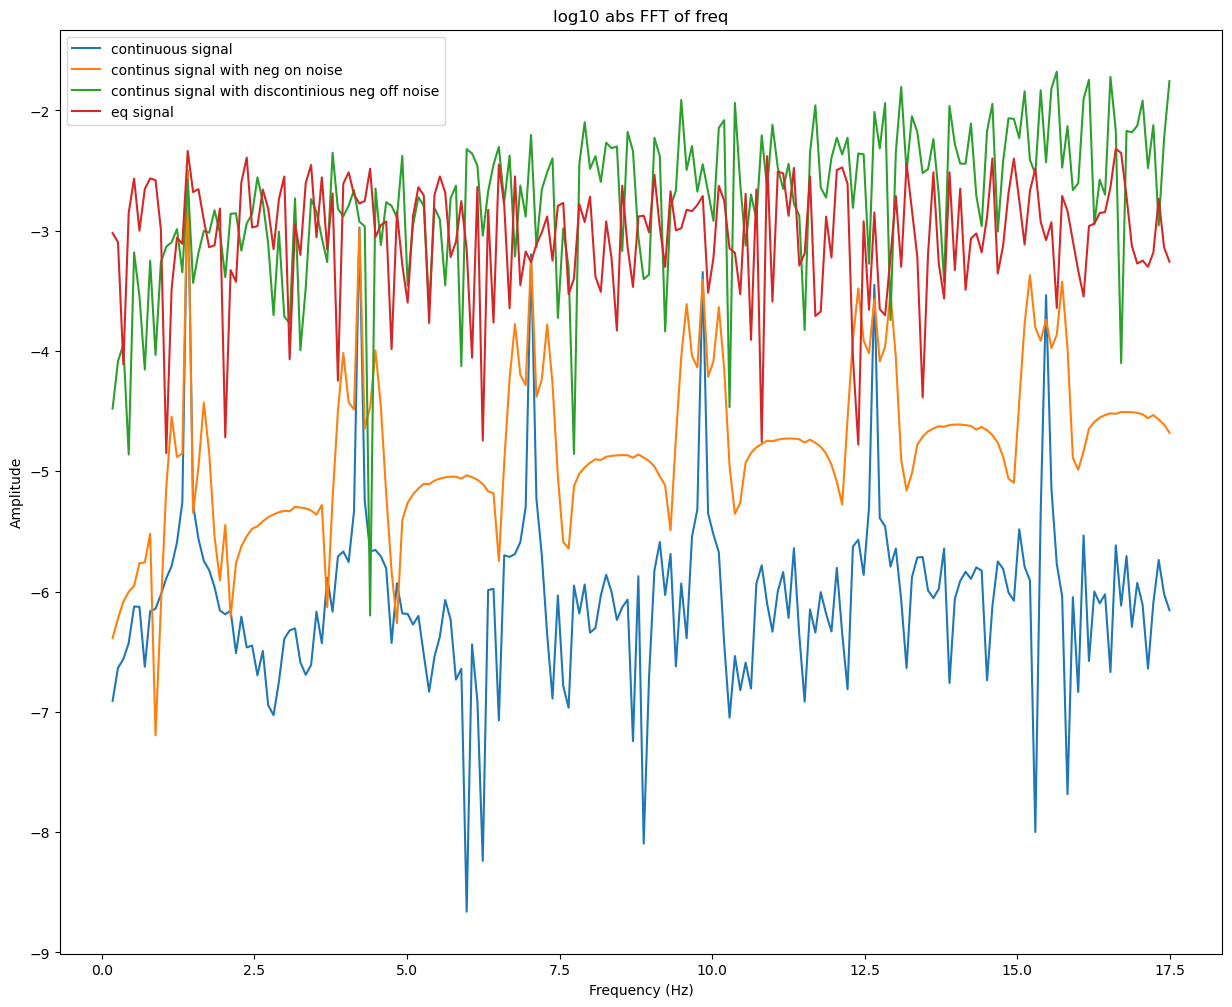

In [25]:
i1 = 2
i2 = 200
plt.figure(figsize=(15, 12))
plt.title('log10 abs FFT of freq')
# plt.plot(f_concat_fit_fft_freqs[i1:i2], np.log10(np.abs(f_concat_fit_fft_abs[i1:i2])),label = "concated signal, right freq")
# plt.plot(f_concat_n0_fit_fft_freqs[i1:i2], np.log10(np.abs(f_concat_n0_fit_fft_abs[i1:i2])),label = "concated signal with noise, fitted phase")
# plt.plot(f_concat_right_fft_freqs[i1:i2], np.log10(np.abs(f_concat_right_fft_abs[i1:i2])),label = "concated signal, right phase")
# plt.plot(f_concat_n0_right_fft_freqs[i1:i2], np.log10(np.abs(f_concat_n0_right_fft_abs[i1:i2])),label = "concated signal with noise, right phase")
plt.plot(f_continuous_fft_freqs[i1:i2], np.log10(np.abs(np.imag(f_continuous_fft_abs[i1:i2]))),label = "continuous signal")
plt.plot(f_continuous_negon_fft_freqs[i1:i2], np.log10(np.abs(np.imag(f_continuous_negon_fft_abs[i1:i2]))),label = "continus signal with neg on noise")
plt.plot(f_continuous_negoff_fft_freqs[i1:i2], np.log10(np.abs(np.imag(f_continuous_negoff_fft_abs[i1:i2]))),label = "continus signal with discontinious neg off noise")
plt.plot(f_eq_fft_freqs[i1:i2], np.log10(np.abs(np.imag(f_eq_fft_abs[i1:i2]))),label = "eq signal")
# plt.plot(f_direct_concat_fft_freqs[i1:i2], np.log10(f_direct_concat_fft_abs[i1:i2]),label = "direct concat signal")
# plt.plot(f_direct_concat_n0_fft_freqs[i1:i2], np.log10(f_direct_concat_n0_fft_abs[i1:i2]),label = "direct concat signal with noise")
# plt.plot(f_concat_tossgap_fft_freqs[i1:i2], np.log10(f_concat_tossgap_fft_abs[i1:i2]),label = "concated signal with tossgap")
# plt.plot(f_concat_n0_tossgap_fft_freqs[i1:i2], np.log10(f_concat_n0_tossgap_fft_abs[i1:i2]),label = "concated signal with noise and tossgap")
plt.legend()

# plt.ylim(-2.,0)
# plt.ylim(np.min(np.log10(freq_fft_abs[10:10000])*2),np.max(np.log10(freq_fft_abs[10:10000])*2))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')

plt.show()

Verification complete. The reduction of noise in the low-frequency region is due to the discontinuity of the noise phase.